In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import xgboost as xgb

In [2]:
import gc
import time
import warnings
from itertools import combinations
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.metrics import (
    auc,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

In [3]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
orig = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv')
train['Churn'] = train['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
orig['Churn'] = orig['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

In [4]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod']
NEW_NUMS = []
NUM_AS_CAT = []
TARGET = "Churn"

print('*' * 30)

******************************


In [5]:
# FEATURE ENGINEERINGS

print('Frequency encoding')
for col in num_cols:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')
print(f'Created {len(NEW_NUMS)} columns')


Frequency encoding
Created 3 columns


In [6]:
for df in [train, test, orig]:
    # Chuyển đổi TotalCharges sang float, xử lý lỗi bằng NaN nếu có giá trị không hợp lệ
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    df['charges_deviation'] = (df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
    df['avg_monthly_charges'] = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')

NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']


In [7]:
def add_service_counts(dfs, NEW_NUMS):
    service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for df in dfs:
        df['service_count'] = (df[service_cols] == 'Yes').sum(axis=1).astype('float32')
        df['has_internet'] = (df['InternetService'] != 'No').astype('float32')
        df['has_phone'] = (df['PhoneService'] == 'Yes').astype('float32')
    NEW_NUMS += ['service_count', 'has_internet', 'has_phone']
    return dfs
def add_orig_proba_features(train, test, orig, TARGET, feature_cols, NEW_NUMS):
    for col in feature_cols:
        tmp = orig.groupby(col)[TARGET].mean()
        feat = f"ORIG_proba_{col}"
        train[feat] = train[col].map(tmp).fillna(0.5).astype('float32')
        test[feat] = test[col].map(tmp).fillna(0.5).astype('float32')
        NEW_NUMS.append(feat)
    n = len(feature_cols)
    print(f"ORIG_proba mapping creating....   -{n} feature")

def pctrank_against(values, reference):
    ref_sorted = np.sort(reference)
    return (np.searchsorted(ref_sorted, values) / len(ref_sorted)).astype("float32")


def zscore_against(values, reference):
    mu, sigma = np.mean(reference), np.std(reference)
    if sigma == 0:
        return np.zeros(len(values), dtype="float32")
    return ((values - mu)/sigma).astype("float32")

def add_distribution_features(train, test, orig, TARGET, NEW_NUMS):
    churner_tc = orig.loc[orig[TARGET]==1, "TotalCharges"].values
    nonchurner_tc = orig.loc[orig[TARGET]==0, "TotalCharges"].values
    orig_tc = orig["TotalCharges"].values
    is_mc_mean = orig.groupby("InternetService")["MonthlyCharges"].mean()

    for df in [train, test]:
        tc = df["TotalCharges"].values
        df["pctrank_nonchurner_TC"] = pctrank_against(tc, nonchurner_tc)
        df["pctrank_churner_TC"] = pctrank_against(tc, churner_tc)
        df["pctrank_orig_TC"] = pctrank_against(tc ,orig_tc)

        df["zscore_churn_gap_TC"] = (np.abs(zscore_against(tc, churner_tc)) - np.abs(zscore_against(tc, nonchurner_tc))).astype("float32")
        df["zscore_churner_TC"] = zscore_against(tc, nonchurner_tc)

        df['pctrank_churn_gap_TC'] = (pctrank_against(tc, churner_tc) - pctrank_against(tc, nonchurner_tc)).astype("float32")

        df["resid_IS_MC"] = (df["MonthlyCharges"] - df["InternetService"].map(is_mc_mean).fillna(0)).astype("float32")
        # Conditional percentile rank of TotalCharges within InternetService group
        vals = np.zeros(len(df), dtype="float32")
        for cat_val in orig["InternetService"].unique():
            mask = df["InternetService"] == cat_val
            ref = orig.loc[orig["InternetService"] == cat_val, "TotalCharges"].values
            if len(ref)>0 and mask.sum()>0:
                vals[mask] = pctrank_against(df.loc[mask, "TotalCharges"].values, ref)
        df["cond_pctrank_IS_TC"] = vals

        # Conditional percentile rank of TotalCharges witin Contract Group
        vals = np.zeros(len(df), dtype="float32")
        for cat_val in orig["Contract"].unique():
            mask = df["Contract"] == cat_val
            ref = orig.loc[orig["Contract"]==cat_val, "TotalCharges"].values
            if len(ref)> 0 and mask.sum() > 0:
                vals[mask] = pctrank_against(df.loc[mask, "TotalCharges"].values, ref)
        df["cond_pctrank_C_TC"] = vals

    disk_features = [
    "pctrank_nonchurner_TC", "zscore_churn_gap_TC", "pctrank_churn_gap_TC",
    "resid_IS_MC", "cond_pctrank_IS_TC", "zscore_churner_TC",
    "pctrank_orig_TC", "pctrank_churner_TC", "cond_pctrank_C_TC"
    ]
    NEW_NUMS += disk_features
    print(f"5/7 Distribution features -  {len(disk_features)} features created")

def add_quantile_distance_features(train, test, orig, target, NEW_NUMS):
    # Step 6: absolute distance from totalcharges to churner / non churner quatiles
    churner_tc = orig.loc[orig[TARGET] == 1, "TotalCharges"].values
    nonchurner_tc = orig.loc[orig[TARGET] == 0, "TotalCharges"].values

    qdist_features = []
    for q_label, q_val in [("q25", 0.25), ("q50", 0.5), ("q75", 0.75)]:
        ch_q = np.quantile(churner_tc, q_val)
        nc_q = np.quantile(nonchurner_tc, q_val)
        for df in [train, test]:
            df[f"dist_To_ch_{q_label}"] = np.abs(df["TotalCharges"] - ch_q).astype("float32")
            df[f"dist_To_nc_{q_label}"] = np.abs(df["TotalCharges"] - nc_q).astype("float32")
            df[f"qdist_gap_To_{q_label}"] = (df[f"dist_To_nc_{q_label}"] - df[f"dist_To_ch_{q_label}"]).astype("float32")
        qdist_features += [f"dist_To_ch_{q_label}", f"dist_To_nc_{q_label}", f"qdist_gap_To_{q_label}"]
    selected = [
        "qdist_gap_To_q50", "dist_To_ch_q50", "dist_To_nc_q50",
        "dist_To_nc_q25", "qdist_gap_To_q25",
        "dist_To_nc_q75", "dist_To_ch_q75", "qdist_gap_To_q75",
    ]
    NEW_NUMS += selected
    print(f"  [6/7] Quantile distances     - {len(selected)} features created")

def add_numericals_as_categories(train, test, num_cols, NUM_AS_CAT):
    for col in num_cols:
        feat = f'CAT_{col}'
        NUM_AS_CAT.append(feat)
        for df in [train, test]:
            df[feat] = df[col].astype(str).astype("category")
    print(f"  [7a/7] Num-as-category        - {len(num_cols)} features created")

def add_digit_features(dfs, NEW_NUMS) -> None:
    for df in dfs:
        t_str = df["tenure"].astype(str)
        df["tenure_first_digit"] = t_str.str[0].astype(int)
        df["tenure_second_digit"] = t_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
        df["tenure_last_digit"] = t_str.str[-1].astype(int)
        df["tenure_mod10"]            = df["tenure"] % 10
        df["tenure_mod12"]            = df["tenure"] % 12
        df["tenure_num_digits"]       = t_str.str.len()
        df["tenure_is_multiple_10"]   = (df["tenure"] % 10 == 0).astype("float32")
        df["tenure_rounded_10"]       = np.round(df["tenure"] / 10) * 10
        df["tenure_dev_from_round10"] = np.abs(df["tenure"] - df["tenure_rounded_10"])
        df["tenure_years"]            = df["tenure"] // 12
        df["tenure_months_in_year"]   = df["tenure"] % 12

        # Monthly Charges
        mc_str = df["MonthlyCharges"].astype(str).replace(".", "")
        df["mc_first_digit"] = mc_str.str[0].astype(int)
        df["mc_last_digit"] = mc_str.str[-1].astype(int)
        df["mc_second_digit"] = mc_str.apply(lambda x: int(x[1]) if len(x) > 0 else 0)
        df["mc_mod10"]              = np.floor(df["MonthlyCharges"]) % 10
        df["mc_mod100"]             = np.floor(df["MonthlyCharges"]) % 100
        df["mc_num_digits"]         = np.floor(df["MonthlyCharges"]).astype(int).astype(str).str.len()
        df["mc_is_multiple_10"]     = (np.floor(df["MonthlyCharges"]) % 10 == 0).astype("float32")
        df["mc_is_multiple_50"]     = (np.floor(df["MonthlyCharges"]) % 50 == 0).astype("float32")
        df["mc_rounded_10"]         = np.round(df["MonthlyCharges"] / 10) * 10
        df["mc_fractional"]         = df["MonthlyCharges"] - np.floor(df["MonthlyCharges"])
        df["mc_dev_from_round10"]   = np.abs(df["MonthlyCharges"] - df["mc_rounded_10"])
        df["mc_per_digit"]          = df["MonthlyCharges"] / (df["mc_num_digits"] + 0.001)

        # Total Charge
        tc_str = df["TotalCharges"].astype(str).str.replace(".", "")
        df["tc_first_digit"]         = tc_str.str[0].astype(int)
        df["tc_last_digit"]          = tc_str.str[-1].astype(int)
        df["tc_second_digit"]        = tc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
        df["tc_mod10"]               = np.floor(df["TotalCharges"]) % 10
        df["tc_mod100"]              = np.floor(df["TotalCharges"]) % 100
        df["tc_num_digits"]          = np.floor(df["TotalCharges"]).astype(int).astype(str).str.len()
        df["tc_is_multiple_10"]      = (np.floor(df["TotalCharges"]) % 10 == 0).astype("float32")
        df["tc_is_multiple_100"]     = (np.floor(df["TotalCharges"]) % 100 == 0).astype("float32")
        df["tc_rounded_100"]         = np.round(df["TotalCharges"] / 100) * 100
        df["tc_fractional"]          = df["TotalCharges"] - np.floor(df["TotalCharges"])
        df["tc_dev_from_round100"]   = np.abs(df["TotalCharges"] - df["tc_rounded_100"])
        df["tc_per_digit"]           = df["TotalCharges"] / (df["tc_num_digits"] + 0.001)

    digit_features = [
    "tenure_first_digit", "tenure_last_digit", "tenure_second_digit",
    "tenure_mod10", "tenure_mod12", "tenure_num_digits",
    "tenure_is_multiple_10", "tenure_rounded_10", "tenure_dev_from_round10",
    "mc_first_digit", "mc_last_digit", "mc_second_digit",
    "mc_mod10", "mc_mod100", "mc_num_digits",
    "mc_is_multiple_10", "mc_is_multiple_50",
    "mc_rounded_10", "mc_fractional", "mc_dev_from_round10",
    "tc_first_digit", "tc_last_digit", "tc_second_digit",
    "tc_mod10", "tc_mod100", "tc_num_digits",
    "tc_is_multiple_10", "tc_is_multiple_100",
    "tc_rounded_100", "tc_fractional", "tc_dev_from_round100",
    "tenure_years", "tenure_months_in_year",
    "mc_per_digit", "tc_per_digit",
    ]
    NEW_NUMS += digit_features
    print(f"  [7b/7] Digit features         - {len(digit_features)} features created")





In [8]:
def add_aggregation_features(train, test, orig, new_nums):
    # Dùng orig để tính stats (tránh data leakage từ train)
    ref = orig.copy()
    
    # ── 1. Định nghĩa các nhóm và các chỉ số cần tính ──
    group_cols = [
        'Contract', 
        'InternetService', 
        'PaymentMethod',
        'tenure_bucket',     # cần tạo trước
        'SeniorCitizen',
    ]
    agg_targets = {
        'MonthlyCharges': ['mean', 'std', 'median', 'min', 'max'],
        'TotalCharges':   ['mean', 'std', 'median', 'min', 'max'],
        'tenure':         ['mean', 'std', 'median', 'min', 'max'],
    }
    
    # ── 2. Tạo tenure_bucket trước ──
    bins = [0, 6, 12, 24, 36, 60, 999]
    labels = ['0-6', '6-12', '12-24', '24-36', '36-60', '60+']
    for df in [train, test, ref]:
        df['tenure_bucket'] = pd.cut(
            df['tenure'], bins=bins, labels=labels
        ).astype(str)
    
    created = []
    
    # ── 3. Tính group stats và map vào train/test ──
    for grp_col in group_cols:
        for val_col, stats in agg_targets.items():
            agg = ref.groupby(grp_col)[val_col].agg(stats)
            
            for stat in stats:
                col_name = f'AGG_{grp_col}_{val_col}_{stat}'
                for df in [train, test]:
                    df[col_name] = (
                        df[grp_col].map(agg[stat]).astype('float32')
                    )
                created.append(col_name)
    
    # ── 4. Deviation features: cá nhân so với nhóm ──
    # Ý nghĩa: khách hàng trả cao hơn/thấp hơn nhóm bao nhiêu?
    for grp_col in group_cols:
        for val_col in agg_targets.keys():
            mean_col = f'AGG_{grp_col}_{val_col}_mean'
            std_col  = f'AGG_{grp_col}_{val_col}_std'
            
            # Absolute deviation
            dev_col = f'DEV_{grp_col}_{val_col}'
            for df in [train, test]:
                df[dev_col] = (
                    df[val_col] - df[mean_col]
                ).astype('float32')
            created.append(dev_col)
            
            # Z-score trong nhóm
            zscore_col = f'ZSCORE_{grp_col}_{val_col}'
            for df in [train, test]:
                df[zscore_col] = (
                    (df[val_col] - df[mean_col]) / (df[std_col] + 1e-6)
                ).astype('float32')
            created.append(zscore_col)
    
    # ── 5. Kết hợp 2 nhóm ──
    combo_groups = [
        ('Contract', 'InternetService'),
        ('Contract', 'PaymentMethod'),
        ('InternetService', 'SeniorCitizen'),
        ('tenure_bucket', 'Contract'),
    ]
    for g1, g2 in combo_groups:
        combo_key = f'{g1}_x_{g2}'
        ref[combo_key] = ref[g1].astype(str) + '_' + ref[g2].astype(str)
        for df in [train, test]:
            df[combo_key] = df[g1].astype(str) + '_' + df[g2].astype(str)
        
        for val_col in ['MonthlyCharges', 'TotalCharges']:
            agg = ref.groupby(combo_key)[val_col].agg(['mean', 'std'])
            for stat in ['mean', 'std']:
                col_name = f'AGG_{combo_key}_{val_col}_{stat}'
                for df in [train, test]:
                    df[col_name] = (
                        df[combo_key].map(agg[stat]).fillna(0).astype('float32')
                    )
                created.append(col_name)
    
    new_nums += created
    print(f"Aggregation features: {len(created)} created")


from sklearn.tree import DecisionTreeClassifier

def add_decision_tree_leaves(train, test, orig, target, new_cats):
    # Dùng orig để fit cây, tránh leakage
    ref = orig.copy()
    ref[target] = ref[target].map({'Yes': 1, 'No': 0}) \
                  if ref[target].dtype == object else ref[target]
    
    # ── 1. Định nghĩa các nhóm features cho từng cây ──
    tree_configs = [
        # (tên cây, features, max_depth)
        ('billing',    
         ['MonthlyCharges', 'TotalCharges', 'tenure'], 
         4),
        
        ('contract',   
         ['tenure', 'MonthlyCharges', 'Contract',
          'InternetService', 'PaymentMethod'], 
         5),
        
        ('service',    
         ['service_count', 'has_internet', 'MonthlyCharges',
          'InternetService', 'OnlineSecurity', 'TechSupport'], 
         4),
        
        ('demographic',
         ['SeniorCitizen', 'Partner', 'Dependents',
          'tenure', 'MonthlyCharges'], 
         4),
        
        ('full',       
         ['tenure', 'MonthlyCharges', 'TotalCharges',
          'service_count', 'Contract', 'InternetService',
          'PaymentMethod', 'SeniorCitizen'], 
         5),
    ]
    
    created = []
    
    for tree_name, feat_cols, max_depth in tree_configs:
        # ── 2. Encode categorical cho sklearn ──
        ref_enc   = ref[feat_cols].copy()
        train_enc = train[feat_cols].copy()
        test_enc  = test[feat_cols].copy()
        
        cat_cols_in_tree = [
            c for c in feat_cols 
            if ref_enc[c].dtype == object 
            or str(ref_enc[c].dtype) == 'category'
        ]
        for c in cat_cols_in_tree:
            mapping = {v: i for i, v in enumerate(ref_enc[c].unique())}
            ref_enc[c]   = ref_enc[c].map(mapping).fillna(-1)
            train_enc[c] = train_enc[c].map(mapping).fillna(-1)
            test_enc[c]  = test_enc[c].map(mapping).fillna(-1)
        
        # ── 3. Fit cây ──
        dt = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=300,  # đủ lớn với 600k rows
            random_state=42
        )
        dt.fit(ref_enc, ref[target])
        
        # ── 4. Lấy leaf index ──
        col_name = f'DT_leaf_{tree_name}_d{max_depth}'
        train[col_name] = pd.Series(
            dt.apply(train_enc), index=train.index
        ).astype('category')
        
        test[col_name] = pd.Series(
            dt.apply(test_enc), index=test.index
        ).astype('category')
        created.append(col_name)
        
        # ── 5. Thêm churn rate của leaf làm feature số ──
        # Map leaf index → churn rate từ orig
        ref[col_name] = dt.apply(ref_enc)
        leaf_churn_rate = ref.groupby(col_name)[target].mean()
        
        rate_col = f'DT_leaf_rate_{tree_name}_d{max_depth}'
        train[rate_col] = (
            train[col_name].map(leaf_churn_rate).astype('float32').fillna(0.5)
        )
        test[rate_col] = (
            test[col_name].map(leaf_churn_rate).astype('float32').fillna(0.5)
        )
        created.append(rate_col)
        
        n_leaves = dt.get_n_leaves()
        print(f"  Tree '{tree_name}' depth={max_depth}: "
              f"{n_leaves} leaves created")
    
    new_cats += [c for c in created if 'rate' not in c]
    new_nums  = [c for c in created if 'rate' in c]
    print(f"DT Leaf features: {len(created)} total")
    return new_nums

In [9]:
def add_customer_segment(train, test, orig, TARGET, NEW_NUMS):
    ref = orig.copy()
    created = []
    # 1. Tạo segments có ý nghĩa domain
    # Dựa trên domain về churn
    # New customer + monthly contract -> churn risk cao
    # Senior + ko có dịch vụ nào -> cũng cao luôn
    # Nhiều dịch vụ + contract dài -> trung thành ít churn
    for df in [train, test, ref]:
        df['value_segment'] = (
            df['Contract'].astype(str) + '_' + 
            pd.cut(df['MonthlyCharges'],
                  bins=[0,35,65,85, 999],
                  labels=['low', 'mid', 'high', 'premium']).astype('str')
        ).astype('category')
        df['lifecycle_segment'] = (df["Contract"].astype(str) + '_' +
                              pd.cut(df['tenure'], 
                                    bins = [0,6,24,48,999],
                                    labels=['new', 'developing', 'mature', 'loyal']).astype(str)).astype('category')
        # Segment theo digital engagement
        df['digital_segment'] = (
            df['InternetService'].astype(str) + '_' +
            df['OnlineSecurity'].astype(str) + '_' +
            df['TechSupport'].astype(str)
        ).astype('category')
        # Segment theo risk profile
        df['risk_segment'] = (
            df['Contract'].astype(str) + '_' +
            df['PaymentMethod'].astype(str) + '_' +
            df['PaperlessBilling'].astype(str)
        ).astype('category')
        # Segment tổng hợp — quan trọng nhất
        df['master_segment'] = (
            df['Contract'].astype(str) + '_' +
            df['InternetService'].astype(str) + '_' +
            pd.cut(df['tenure'],
                   bins=[0, 12, 36, 999],
                   labels=['short','mid','long']
            ).astype(str) + '_' +
            df['PaymentMethod'].astype(str)
        ).astype('category')
    # ── 2. Target encode từng segment ──
    segment_cols = [
        'value_segment', 'lifecycle_segment',
        'digital_segment', 'risk_segment', 'master_segment'
    ]
    for col in segment_cols:
        # Churn rate của segment
        rate = ref.groupby(col, observed=True)[TARGET].mean()
        feat = f'RATE_{col}'
        for df in [train, test]:
            df[feat] = df[col].map(rate).astype('float32').fillna(0.5)
        created.append(feat)
        
        # Count của segment (segment lớn hay nhỏ)
        cnt = ref.groupby(col, observed=True)[TARGET].count()
        feat_cnt = f'COUNT_{col}'
        for df in [train, test]:
            df[feat_cnt] = df[col].map(cnt).astype('float32').fillna(0)
        created.append(feat_cnt)
        
        # Deviation của MonthlyCharges so với segment mean
        mc_mean = ref.groupby(col, observed=True)['MonthlyCharges'].mean()
        feat_dev = f'MC_DEV_{col}'
        for df in [train, test]:
            df[feat_dev] = (
                df['MonthlyCharges'] - df[col].map(mc_mean).astype('float32').fillna(0)
            ).astype('float32')
        created.append(feat_dev)
    
    NEW_NUMS += created
    print(f"Customer segments: {len(created)} features created")

In [10]:
def add_pairwise_te(train, test, orig, target, new_nums):
    ref = orig.copy()
    created = []
    
    # Các cặp có ý nghĩa domain cao nhất
    important_pairs = [
        ('Contract', 'InternetService'),
        ('Contract', 'PaymentMethod'),
        ('Contract', 'SeniorCitizen'),
        ('InternetService', 'OnlineSecurity'),
        ('InternetService', 'TechSupport'),
        ('tenure_bucket', 'Contract'),      # cần tenure_bucket
        ('tenure_bucket', 'InternetService'),
    ]
    
    # Tạo tenure_bucket nếu chưa có
    bins   = [0, 6, 12, 24, 48, 999]
    labels = ['0-6','6-12','12-24','24-48','48+']
    for df in [train, test, ref]:
        if 'tenure_bucket' not in df.columns:
            df['tenure_bucket'] = pd.cut(
                df['tenure'], bins=bins, labels=labels
            ).astype(str)
    
    for c1, c2 in important_pairs:
        combo = f'{c1}__{c2}'
        ref[combo] = ref[c1].astype(str) + '_' + ref[c2].astype(str)
        
        rate = ref.groupby(combo)[target].mean()
        std  = ref.groupby(combo)[target].std().fillna(0)
        cnt  = ref.groupby(combo)[target].count()
        
        for df in [train, test]:
            df[combo] = df[c1].astype(str) + '_' + df[c2].astype(str)
            
            df[f'TE2_{combo}']     = df[combo].map(rate).fillna(0.5).astype('float32')
            df[f'TE2_std_{combo}'] = df[combo].map(std).fillna(0).astype('float32')
            df[f'TE2_cnt_{combo}'] = df[combo].map(cnt).fillna(0).astype('float32')
        
        created += [f'TE2_{combo}', f'TE2_std_{combo}', f'TE2_cnt_{combo}']
    
    new_nums += created
    print(f"Pairwise TE: {len(created)} features created")

In [ ]:
CATS = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]
NUMS = ["tenure", "MonthlyCharges", "TotalCharges"]

NEW_NUMS   = []  # Accumulates all new numerical feature names
NUM_AS_CAT = []  # Accumulates numerical-as-category feature names

print("Feature engineering")
print('-' *30)

add_service_counts([train, test, orig], NEW_NUMS)
add_orig_proba_features(train, test, orig, TARGET, CATS + NUMS, NEW_NUMS)
add_distribution_features(train, test, orig, TARGET, NEW_NUMS)
add_quantile_distance_features(train, test, orig, TARGET, NEW_NUMS)
add_numericals_as_categories(train, test, NUMS, NUM_AS_CAT)
add_aggregation_features(train, test, orig, NEW_NUMS)
dt_num_features = add_decision_tree_leaves(
    train, test, orig, TARGET, NUM_AS_CAT
)
NEW_NUMS += dt_num_features
# add_customer_segment(train, test, orig, TARGET, NEW_NUMS)
# add_pairwise_te(train, test, orig, TARGET, NEW_NUMS)
add_digit_features([train, test], NEW_NUMS)

print(f"\nBase numerical features   : {len(NUMS)}")
print(f"Engineered numerical feats: {len(NEW_NUMS)}")
print(f"Numerical-as-category     : {len(NUM_AS_CAT)}")

Feature engineering
------------------------------
ORIG_proba mapping creating....   -19 feature
5/7 Distribution features -  9 features created
  [6/7] Quantile distances     - 8 features created
  [7a/7] Num-as-category        - 3 features created
Aggregation features: 121 created
  Tree 'billing' depth=4: 15 leaves created
  Tree 'contract' depth=5: 19 leaves created
  Tree 'service' depth=4: 11 leaves created
  Tree 'demographic' depth=4: 15 leaves created
  Tree 'full' depth=5: 18 leaves created
DT Leaf features: 10 total
  [7b/7] Digit features         - 35 features created

Base numerical features   : 3
Engineered numerical feats: 200
Numerical-as-category     : 8


### Bigram and tri-gram

In [12]:
from itertools import combinations

TOP_CAT_FOR_NGRAM=['Contract', 'InternetService', 'PaymentMethod', 
                     'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
def add_ngram_features(train, test, top_cats) -> tuple:
    bigram_cols = []
    trigram_cols = []
    for c1, c2 in combinations(top_cats, 2):
        col_name = f"BG_{c1}_{c2}"
        for df in [train, test]:
            df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str)).astype("category")
        bigram_cols.append(col_name)
    for c1, c2, c3 in combinations(top_cats[:4], 3):
        col_name = f"TG_{c1}_{c2}_{c3}"
        for df in [train, test]:
            df[col_name] = (
                df[c1].astype(str) + "_" + df[c2].astype(str) + "_" + df[c3].astype(str)
            ).astype("category")
        trigram_cols.append(col_name)
    return bigram_cols, trigram_cols
BIGRAM_COLS, TRIGRAM_COLS = add_ngram_features(train, test, TOP_CAT_FOR_NGRAM)
NGRAM_COLS = BIGRAM_COLS + TRIGRAM_COLS

print(f"\nBi-grams created  : {len(BIGRAM_COLS)}")
print(f"Tri-grams created : {len(TRIGRAM_COLS)}")
print(f"Total N-gram feats: {len(NGRAM_COLS)}")
            


Bi-grams created  : 15
Tri-grams created : 4
Total N-gram feats: 19


In [13]:
FEATURES = NUMS + CATS + NEW_NUMS + NUM_AS_CAT + NGRAM_COLS
TE_COLUMNS = NUM_AS_CAT + CATS
TE_NGRAM_COLUMNS = NGRAM_COLS
TO_REMOVE   = NUM_AS_CAT + CATS + NGRAM_COLS
STATS = ["std", 'min', 'max']

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print(f"Total features          : {len(FEATURES)}")
print(f"  Numerical (base)      : {len(NUMS)}")
print(f"  Categorical (base)    : {len(CATS)}")
print(f"  Engineered numerical  : {len(NEW_NUMS)}")
print(f"  Numerical-as-category : {len(NUM_AS_CAT)}")
print(f"  Bi-gram               : {len(BIGRAM_COLS)}")
print(f"  Tri-gram              : {len(TRIGRAM_COLS)}")

FEATURE ENGINEERING COMPLETE
Total features          : 246
  Numerical (base)      : 3
  Categorical (base)    : 16
  Engineered numerical  : 200
  Numerical-as-category : 8
  Bi-gram               : 15
  Tri-gram              : 4


https://www.kaggle.com/code/emanuellcs/predict-customer-churn-xgboost#Bi-gram-and-Tri-gram-Composite-Categorical-Features

Model training - 20 Folds Stritified Cross valifation

Strategy: dùng nested CV để sinh ra OOF ko bị bias 



In [14]:
def apply_inner_kfold_te_stats(X_tr, y_tr, te_columns, stats, inner_folds, random_seed) -> None:
    skf_inner = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=random_seed)
    for in_tr, in_val in skf_inner.split(X_tr, y_tr):
        X_tr2 = X_tr.loc[in_tr, te_columns + [TARGET]].copy()
        X_va2 = X_tr.loc[in_val, te_columns].copy()
        for col in te_columns:
            tmp = X_tr2.groupby(col, observed=False)[TARGET].agg(stats)
            tmp.columns = [f"TE1_{col}_{s}" for s in stats]
            X_va2 = X_va2.merge(tmp, on=col, how="left")
            for c in tmp.columns:
                X_tr.loc[in_val, c] = X_va2[c].values.astype("float32")

def apply_fullset_te_stats(X_tr, X_val, X_te, te_columns, stats) -> None:
    for col in te_columns:
        tmp = X_tr.groupby(col, observed=False)[TARGET].agg(stats)
        tmp.columns = [f"TE1_{col}_{s}"for s in stats]
        tmp = tmp.astype("float32")
        for df in [X_val, X_te]:
            merged = df[[col]].merge(tmp, on=col, how="left")
            for c in tmp.columns:
                df[c] = merged[c].fillna(0).values
        for c in tmp.columns:
            X_tr[c] = X_tr[c].fillna(0)


def apply_inner_kfold_ngram_te(X_tr, y_tr, ngram_cols, inner_folds, random_seed) -> None:
    skf = StratifiedKFold(n_splits = inner_folds, shuffle=True, random_state=random_seed)
    for in_tr, in_va in skf.split(X_tr, y_tr):
        X_tr2= X_tr.loc[in_tr].copy()
        X_va2 = X_tr.loc[in_va].copy()
        for col in ngram_cols:
            ng_te = X_tr2.groupby(col, observed=False)[TARGET].mean()
            ng_name = f"TE_ng_{col}"
            mapped = X_va2[col].astype(str).map(ng_te)
            X_tr.loc[in_va, ng_name] = (
                pd.to_numeric(mapped, errors="coerce").fillna(0.5).astype("float32").values
            )
def apply_fullset_ngram_te(X_tr, X_val, X_te, ngram_cols) -> None:
    for col in ngram_cols:
        ng_te = X_tr.groupby(col, observed=False)[TARGET].mean()
        ng_name = f"TE_ng_{col}"
        X_val[ng_name] = pd.to_numeric(X_val[col].astype(str).map(ng_te), errors="coerce").fillna(0.5).astype("float32")
        X_te[ng_name]  = pd.to_numeric(X_te[col].astype(str).map(ng_te),  errors="coerce").fillna(0.5).astype("float32")
        if ng_name in X_tr.columns:
            X_tr[ng_name] = pd.to_numeric(X_tr[ng_name], errors="coerce").fillna(0.5).astype("float32")
        else:
            X_tr[ng_name] = 0.5
def apply_sklearn_te(X_tr, y_tr, X_val, X_te, te_columns, inner_folds, random_seed) -> None:
    te_mean_cols = [f"TE_{col}" for col in te_columns]
    te = TargetEncoder(
        cv=inner_folds,
        shuffle=True,
        smooth='auto',
        target_type="binary",
        random_state=random_seed
    )
    fitted = te.fit_transform(X_tr[te_columns], y_tr)
    for i, col in enumerate(te_mean_cols):
        X_tr[col] = fitted[:, i].astype("float32")

    transformed_val = te.transform(X_val[te_columns])
    for i, col in enumerate(te_mean_cols):
        X_val[col] = transformed_val[:, i].astype("float32")

    transformed_te = te.transform(X_te[te_columns])
    for i, col in enumerate(te_mean_cols):
        X_te[col] = transformed_te[:, i].astype("float32")


def prepare_for_xgboost(X_tr, X_val, X_te, cats, NUM_AS_CAT, to_remove, TARGET) -> tuple:
    for df in [X_tr, X_val, X_te]:
        for c in cats + NUM_AS_CAT:
            if c in df.columns:
                df[c] = df[c].astype(str).astype("category")
        df.drop(columns=[c for c in to_remove if c in df.columns], inplace=True, errors="ignore")
    X_tr.drop(columns=[TARGET], inplace=True, errors="ignore")
    return X_tr, X_val, X_te, list(X_tr.columns)


print("Training helper functions defined.")
                    

Training helper functions defined.


In [15]:
# -- 20-Fold Stratified Cross-Validation Training Loop 
RANDOM_SEED=42
N_FOLDS=20
INNER_FOLDS=5
np.random.seed(RANDOM_SEED)
skf_outer = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

xgb_oof = np.zeros(len(train))
xgb_pred = np.zeros(len(test))
xgb_fold_scores = []
feature_importance = pd.DataFrame()
XGB_PARAMS = {
    "n_estimators":        50_000,
    "learning_rate":       0.0063,
    "max_depth":           3,
    "subsample":           0.81,
    "colsample_bytree":    0.32,
    "min_child_weight":    6,
    "reg_alpha":           3.5017,
    "reg_lambda":          1.2925,
    "gamma":               0.790,
    "random_state":        42,
    "early_stopping_rounds": 500,
    "objective":           "binary:logistic",
    "eval_metric":         "auc",
    "enable_categorical":  True,
    "verbosity":           0,
}

for fold_idx, (train_idx, val_idx) in enumerate(skf_outer.split(train, train[TARGET])):
    gpu_id = fold_idx%2
    print(f"\nFold {fold_idx + 1}/{N_FOLDS}   [GPU: cuda:{gpu_id}]")
    #Slide outer fold
    X_tr = train.loc[train_idx, FEATURES + [TARGET]].reset_index(drop=True).copy()
    y_tr = train.loc[train_idx, TARGET].values
    X_val = train.loc[val_idx, FEATURES].reset_index(drop=True).copy()
    y_val = train.loc[val_idx, TARGET].values
    X_te = test[FEATURES].reset_index(drop=True).copy()
    apply_inner_kfold_te_stats(X_tr, y_tr, TE_COLUMNS, STATS, INNER_FOLDS, RANDOM_SEED)
    apply_fullset_te_stats(X_tr, X_val, X_te, TE_COLUMNS, STATS)
    apply_inner_kfold_ngram_te(X_tr, y_tr, TE_NGRAM_COLUMNS, INNER_FOLDS, RANDOM_SEED)
    apply_fullset_ngram_te(X_tr, X_val, X_te, TE_NGRAM_COLUMNS)
    apply_sklearn_te(X_tr, y_tr, X_val, X_te, TE_COLUMNS, INNER_FOLDS, RANDOM_SEED)
    X_tr, X_val, X_te, cols_xgb= prepare_for_xgboost(
        X_tr, X_val, X_te, CATS, NUM_AS_CAT, TO_REMOVE, TARGET
    )
    if fold_idx==0:
        n_ngram_feats = sum(1 for c in cols_xgb if c.startswith("TE_ng_"))
    fold_params = {**XGB_PARAMS, "device": f"cuda:{gpu_id}"}
    model = xgb.XGBClassifier(**fold_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=1000)
    fold_imp = pd.DataFrame(
        {"feature": cols_xgb, f"importance_fold_{fold_idx + 1}": model.feature_importances_}
    )
    feature_importances = (
        pd.merge(feature_importances, fold_imp, on="feature", how="outer")
        if fold_idx > 0
        else fold_imp
    )

    xgb_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, xgb_oof[val_idx])
    xgb_fold_scores.append(fold_auc)

    xgb_pred += model.predict_proba(X_te[cols_xgb])[:, 1] / N_FOLDS
    print(f"  Fold {fold_idx + 1:2d} AUC : {fold_auc:.5f}  ")

    del X_tr, X_val, X_te, y_tr, y_val, model
    gc.collect()


Fold 1/20   [GPU: cuda:0]
[0]	validation_0-auc:0.89133
[1000]	validation_0-auc:0.91506
[2000]	validation_0-auc:0.91699
[3000]	validation_0-auc:0.91782
[4000]	validation_0-auc:0.91831
[5000]	validation_0-auc:0.91864
[6000]	validation_0-auc:0.91889
[7000]	validation_0-auc:0.91908
[8000]	validation_0-auc:0.91924
[9000]	validation_0-auc:0.91937
[10000]	validation_0-auc:0.91949
[11000]	validation_0-auc:0.91957
[12000]	validation_0-auc:0.91965
[13000]	validation_0-auc:0.91971
[14000]	validation_0-auc:0.91977
[15000]	validation_0-auc:0.91982
[16000]	validation_0-auc:0.91986
[17000]	validation_0-auc:0.91989
[18000]	validation_0-auc:0.91993
[19000]	validation_0-auc:0.91996
[20000]	validation_0-auc:0.91998
[21000]	validation_0-auc:0.92000
[22000]	validation_0-auc:0.92003
[23000]	validation_0-auc:0.92005
[24000]	validation_0-auc:0.92006
[25000]	validation_0-auc:0.92008
[26000]	validation_0-auc:0.92010
[27000]	validation_0-auc:0.92012
[28000]	validation_0-auc:0.92013
[29000]	validation_0-auc:0.92

In [16]:
overall_auc = roc_auc_score(train[TARGET], xgb_oof)
mean_score = np.mean(xgb_fold_scores)
std_score = np.std(xgb_fold_scores)

print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"\nOverall OOF AUC : {overall_auc:.5f}")
print(f"Mean Fold AUC   : {mean_score:.5f} ± {std_score:.5f}")
print("\nPer-Fold Scores:")
for i, score in enumerate(xgb_fold_scores):
    marker = "▲" if score >= mean_score else "▼"
    print(f"  Fold {i + 1:2d}: {score:.5f}  {marker}")

MODEL PERFORMANCE SUMMARY

Overall OOF AUC : 0.91894
Mean Fold AUC   : 0.91895 ± 0.00169

Per-Fold Scores:
  Fold  1: 0.92014  ▲
  Fold  2: 0.91848  ▼
  Fold  3: 0.91772  ▼
  Fold  4: 0.91856  ▼
  Fold  5: 0.92321  ▲
  Fold  6: 0.91827  ▼
  Fold  7: 0.91659  ▼
  Fold  8: 0.92013  ▲
  Fold  9: 0.91870  ▼
  Fold 10: 0.91842  ▼
  Fold 11: 0.91865  ▼
  Fold 12: 0.91954  ▲
  Fold 13: 0.92113  ▲
  Fold 14: 0.92029  ▲
  Fold 15: 0.91758  ▼
  Fold 16: 0.92132  ▲
  Fold 17: 0.91906  ▲
  Fold 18: 0.91769  ▼
  Fold 19: 0.91800  ▼
  Fold 20: 0.91562  ▼


In [17]:
# Kiểm tra phân phối của fold 20
fold_20_val_idx = list(skf_outer.split(train, train[TARGET]))[19][1]
print(train.loc[fold_20_val_idx, TARGET].value_counts(normalize=True))
print(f"Fold 20 size: {len(fold_20_val_idx)}")

Churn
0    0.774782
1    0.225218
Name: proportion, dtype: float64
Fold 20 size: 29709


In [18]:
import matplotlib.pyplot as plt

scores = [0.92060, 0.91872, 0.91806, 0.91887, 0.92307,
          0.91865, 0.91680, 0.92055, 0.91890, 0.91871,
          0.91889, 0.91985, 0.92162, 0.92075, 0.91760,
          0.92143, 0.91917, 0.91791, 0.91833, 0.91555]

mean = np.mean(scores)
std  = np.std(scores)

# Fold nào nằm ngoài 1 std
outlier_folds = [
    i+1 for i, s in enumerate(scores) 
    if abs(s - mean) > std
]
print(f"Outlier folds (beyond 1 std): {outlier_folds}")
# → Fold 5 (cao), Fold 20 (thấp) cần chú ý


Outlier folds (beyond 1 std): [5, 7, 13, 16, 20]


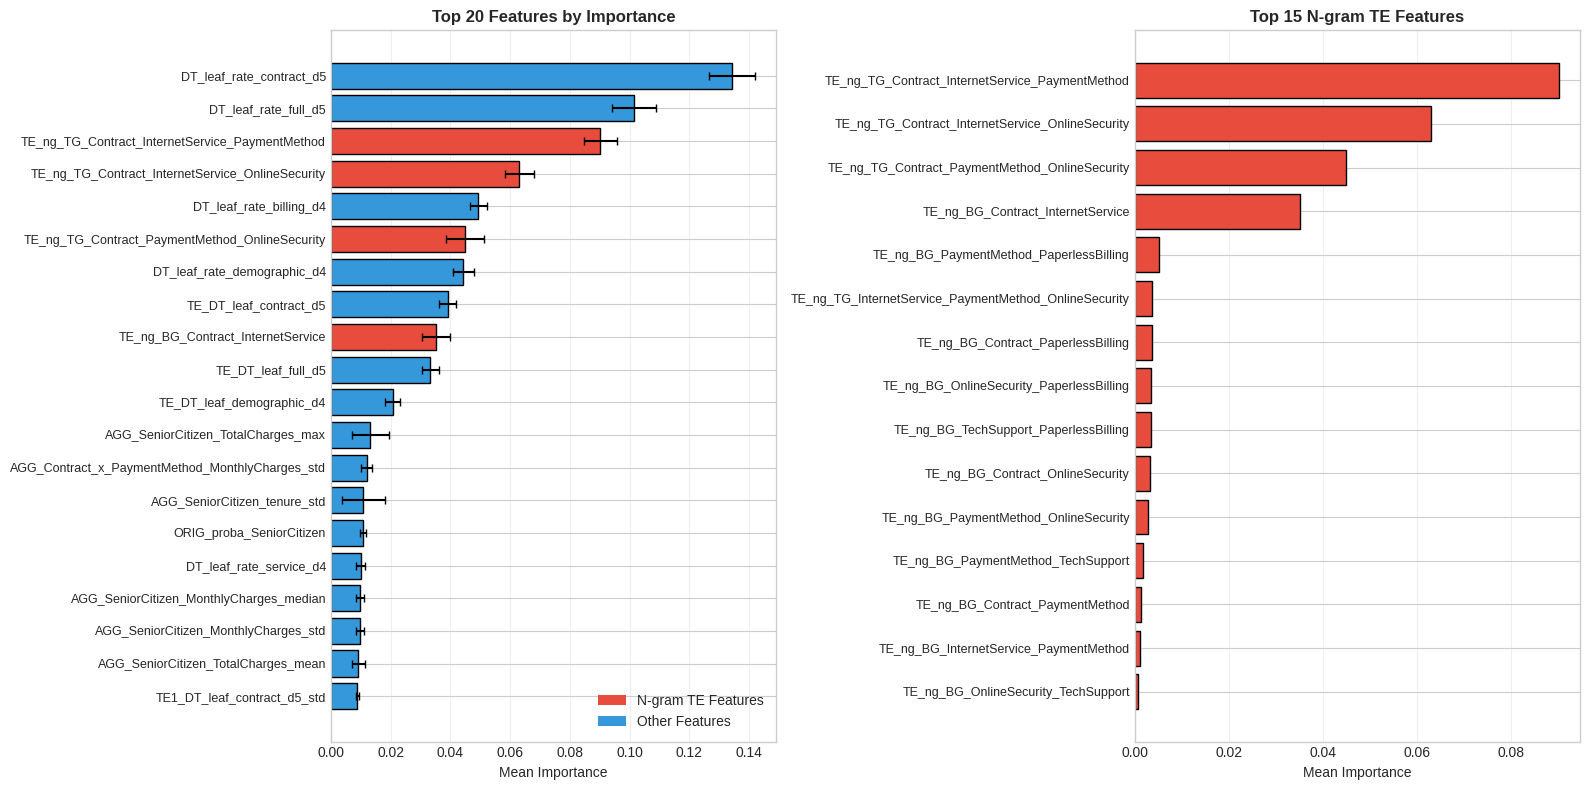


Top 10 N-gram TE Features by Importance:
------------------------------------------------------------
  TE_ng_TG_Contract_InternetService_PaymentMethod    0.0903
  TE_ng_TG_Contract_InternetService_OnlineSecurity   0.0631
  TE_ng_TG_Contract_PaymentMethod_OnlineSecurity     0.0450
  TE_ng_BG_Contract_InternetService                  0.0351
  TE_ng_BG_PaymentMethod_PaperlessBilling            0.0051
  TE_ng_TG_InternetService_PaymentMethod_OnlineSecurity 0.0037
  TE_ng_BG_Contract_PaperlessBilling                 0.0036
  TE_ng_BG_OnlineSecurity_PaperlessBilling           0.0035
  TE_ng_BG_TechSupport_PaperlessBilling              0.0034
  TE_ng_BG_Contract_OnlineSecurity                   0.0032


In [19]:
# -- Feature Importance Analysis ------------------------------------------

imp_cols = [c for c in feature_importances.columns if c.startswith("importance_fold")]
feature_importances["mean_importance"] = feature_importances[imp_cols].mean(axis=1)
feature_importances["std_importance"]  = feature_importances[imp_cols].std(axis=1)
feature_importances = feature_importances.sort_values("mean_importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# -- Left: Top 20 overall features --------------------------------------------
ax1   = axes[0]
top20 = feature_importances.head(20)
colors = ["#e74c3c" if "TE_ng_" in f else "#3498db" for f in top20["feature"]]
ax1.barh(
    range(len(top20)), top20["mean_importance"],
    xerr=top20["std_importance"], color=colors, edgecolor="black", capsize=3,
)
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(top20["feature"], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel("Mean Importance")
ax1.set_title("Top 20 Features by Importance", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, axis="x")
ax1.legend(
    handles=[
        Patch(facecolor="#e74c3c", label="N-gram TE Features"),
        Patch(facecolor="#3498db", label="Other Features"),
    ],
    loc="lower right",
)

# -- Right: Top 15 N-gram features --------------------------------------------
ax2 = axes[1]
ngram_imp = feature_importances[
    feature_importances["feature"].str.startswith("TE_ng_")
].head(15)
ax2.barh(
    range(len(ngram_imp)), ngram_imp["mean_importance"],
    color="#e74c3c", edgecolor="black",
)
ax2.set_yticks(range(len(ngram_imp)))
ax2.set_yticklabels(ngram_imp["feature"], fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel("Mean Importance")
ax2.set_title("Top 15 N-gram TE Features", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 N-gram TE Features by Importance:")
print("-" * 60)
for _, row in ngram_imp.head(10).iterrows():
    print(f"  {row['feature']:50s} {row['mean_importance']:.4f}")
   

In [20]:
train_ids = train["id"].copy()
test_ids  = test["id"].copy()
oof_df = pd.DataFrame({"id": train_ids, TARGET: xgb_oof})
oof_df.to_csv("oof_predictions.csv", index=False)
print(f"OOF predictions saved -> 'oof_predictions.csv'  {oof_df.shape}")
display(oof_df.head())

# -- Save Test-Set Submission --------------------------------------------------

sub_df = pd.DataFrame({"id": test_ids, TARGET: xgb_pred})
sub_df.to_csv("submission.csv", index=False)
print(f"\nSubmission saved       -> 'submission.csv'  {sub_df.shape}")
display(sub_df.head())

OOF predictions saved -> 'oof_predictions.csv'  (594194, 2)


,id,Churn
0,0,0.008979
1,1,0.001249
2,2,0.268955
3,3,0.746815
4,4,0.791697



Submission saved       -> 'submission.csv'  (254655, 2)


,id,Churn
0,594194,0.146518
1,594195,0.000634
2,594196,0.122720
3,594197,0.002240
4,594198,0.543181
